# 05 - SMC Bias Engine (H4)
Swing High/Low → BOS → CHoCH → Bias

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

rates = mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_H4, 0, 1000)
mt5.shutdown()

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df = df.set_index('time')

print(f'EURUSD: {len(df)} H4 bars')
print(f'Range: {df.index[0]} to {df.index[-1]}')

EURUSD: 1000 H4 bars
Range: 2025-10-07 12:00:00 to 2026-06-01 00:00:00


## 1. Swing High/Low Detector
Local highs/lows na may **left and right confirmation candles**

In [23]:
def find_swings(df, left=2, right=2):
    """Find swing highs and lows.
    left/right = number of candles on each side for confirmation.
    """
    highs = []
    lows = []

    for i in range(left, len(df) - right):
        window_high = df['high'].iloc[i-left:i+right+1]
        window_low = df['low'].iloc[i-left:i+right+1]

        if df['high'].iloc[i] == window_high.max():
            highs.append({
                'index': df.index[i],
                'price': df['high'].iloc[i],
                'type': 'swing_high'
            })

        if df['low'].iloc[i] == window_low.min():
            lows.append({
                'index': df.index[i],
                'price': df['low'].iloc[i],
                'type': 'swing_low'
            })

    swings = pd.DataFrame(highs + lows).sort_values('index').reset_index(drop=True)
    return swings

swings = find_swings(df, left=2, right=2)
print(f'Swing Highs: {(swings["type"]=="swing_high").sum()}')
print(f'Swing Lows:  {(swings["type"]=="swing_low").sum()}')
swings.tail(10)

Swing Highs: 132
Swing Lows:  138


,index,price,type
260,2026-05-22 16:00:00,1.15877,swing_low
261,2026-05-25 00:00:00,1.16485,swing_high
262,2026-05-25 12:00:00,1.16523,swing_high
263,2026-05-26 12:00:00,1.16445,swing_high
264,2026-05-26 16:00:00,1.16158,swing_low
265,2026-05-27 12:00:00,1.16608,swing_high
266,2026-05-28 04:00:00,1.15856,swing_low
267,2026-05-28 16:00:00,1.16607,swing_high
268,2026-05-29 08:00:00,1.16244,swing_low
269,2026-05-29 16:00:00,1.16852,swing_high


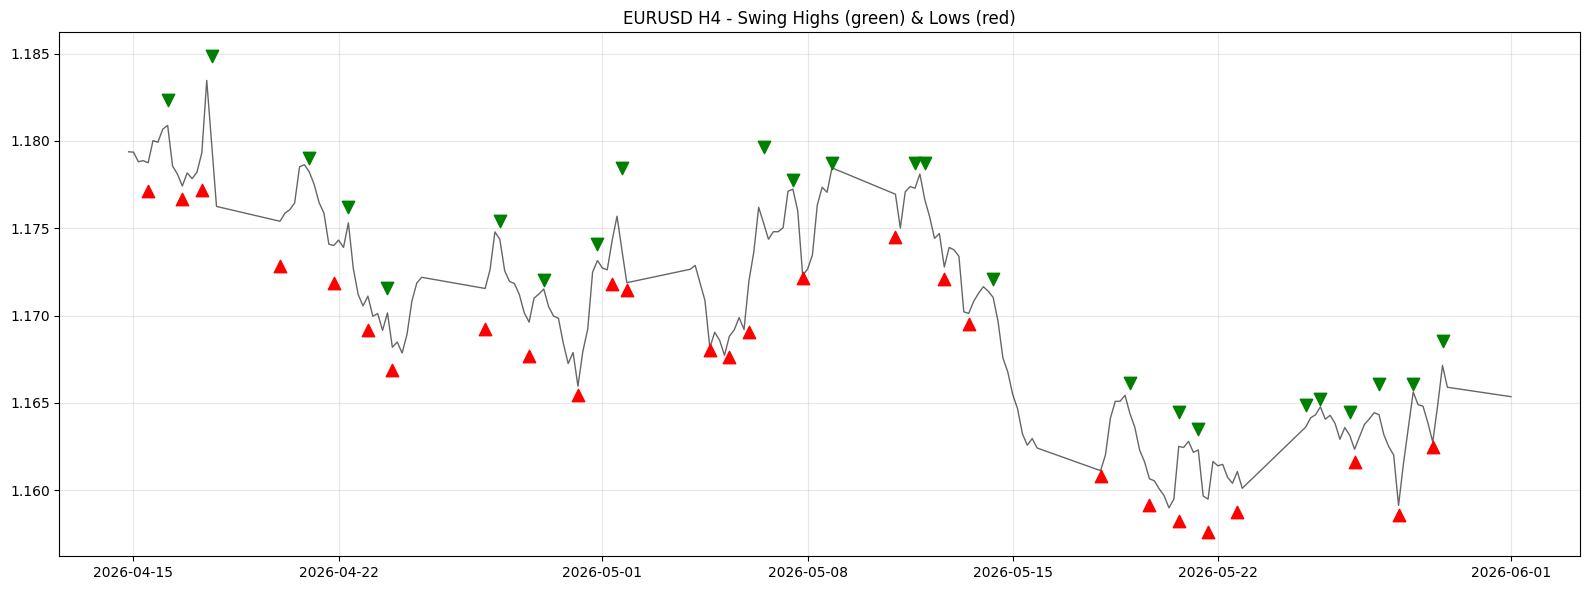

In [24]:
# Visualize swings
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index[-200:], df['close'].iloc[-200:], color='black', linewidth=1, alpha=0.6)

recent = swings[swings['index'] >= df.index[-200]]
for _, s in recent.iterrows():
    color = 'green' if s['type'] == 'swing_high' else 'red'
    marker = 'v' if s['type'] == 'swing_high' else '^'
    ax.scatter(s['index'], s['price'], color=color, marker=marker, s=80, zorder=5)

ax.set_title('EURUSD H4 - Swing Highs (green) & Lows (red)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. BOS (Break of Structure) Detector
Price breaks previous swing high/low = **BOS** (trend continues)

In [25]:
def detect_bos(df, swings):
    """Detect Break of Structure."""
    swing_highs = swings[swings['type'] == 'swing_high'].reset_index(drop=True)
    swing_lows = swings[swings['type'] == 'swing_low'].reset_index(drop=True)

    bos_signals = []

    # BOS (Uptrend) — price breaks above last swing high
    for i in range(1, len(swing_highs)):
        prev_high = swing_highs.iloc[i-1]
        curr_high = swing_highs.iloc[i]
        # Check if price went higher between them
        mask = (df.index > prev_high['index']) & (df.index < curr_high['index'])
        between = df.loc[mask]
        if len(between) > 0 and between['close'].max() > prev_high['price']:
            bos_signals.append({
                'time': prev_high['index'],
                'type': 'BOS',
                'direction': 'bullish',
                'broken_level': prev_high['price'],
                'description': f'Bullish BOS — broke {prev_high["price"]:.5f}'
            })

    # BOS (Downtrend) — price breaks below last swing low
    for i in range(1, len(swing_lows)):
        prev_low = swing_lows.iloc[i-1]
        curr_low = swing_lows.iloc[i]
        mask = (df.index > prev_low['index']) & (df.index < curr_low['index'])
        between = df.loc[mask]
        if len(between) > 0 and between['close'].min() < prev_low['price']:
            bos_signals.append({
                'time': prev_low['index'],
                'type': 'BOS',
                'direction': 'bearish',
                'broken_level': prev_low['price'],
                'description': f'Bearish BOS — broke {prev_low["price"]:.5f}'
            })

    return pd.DataFrame(bos_signals).sort_values('time').reset_index(drop=True) if bos_signals else pd.DataFrame()

bos = detect_bos(df, swings)
if len(bos) > 0:
    print(f'BOS detected: {len(bos)}')
    print(f'Bullish: {(bos["direction"]=="bullish").sum()} | Bearish: {(bos["direction"]=="bearish").sum()}')
    bos.tail(10)
else:
    print('No BOS detected')

BOS detected: 73
Bullish: 32 | Bearish: 41


## 3. CHoCH (Change of Character) Detector
Trend reversal signal — previous swing structure breaks = **CHoCH**

In [26]:
def detect_choch(df, swings, max_candles_ahead=30):
    """Detect CHoCH (trend reversal).
    Requires PRIOR TREND before reversal:
      Bearish: prior HH (i-2 < i-1) → LH (i < i-1) → break swing low
      Bullish: prior LL (i-2 > i-1) → HL (i > i-1) → break swing high
    Forward window limited — no lookahead bias.
    """
    swing_highs = swings[swings['type'] == 'swing_high'].reset_index(drop=True)
    swing_lows = swings[swings['type'] == 'swing_low'].reset_index(drop=True)
    signals = []
    broken_low_times = set()
    broken_high_times = set()

    def last_before(series, time):
        m = series[series['index'] < time]
        return m.iloc[-1] if len(m) > 0 else None

    def idx_loc(t):
        return df.index.get_loc(t) if t in df.index else None

    # Bearish CHoCH
    for i in range(2, len(swing_highs)):
        curr, prev, pp = swing_highs.iloc[i], swing_highs.iloc[i-1], swing_highs.iloc[i-2]
        # Need prior uptrend: pp < prev (HH) then curr < prev (LH)
        if not (pp['price'] < prev['price'] and curr['price'] < prev['price']):
            continue
        break_low = last_before(swing_lows, curr['index'])
        if break_low is None or break_low['index'] in broken_low_times:
            continue
        pos = idx_loc(curr['index'])
        if pos is None:
            continue
        window = df.iloc[pos:min(pos + max_candles_ahead + 1, len(df))]
        if len(window) > 0 and window['low'].min() < break_low['price']:
            signals.append({'time': window['low'].idxmin(), 'type': 'CHoCH', 'direction': 'bearish',
                'description': f'Bearish — HH={pp["price"]:.5f}→{prev["price"]:.5f}, LH={curr["price"]:.5f}, broke {break_low["price"]:.5f}'})
            broken_low_times.add(break_low['index'])

    # Bullish CHoCH
    for i in range(2, len(swing_lows)):
        curr, prev, pp = swing_lows.iloc[i], swing_lows.iloc[i-1], swing_lows.iloc[i-2]
        # Need prior downtrend: pp > prev (LL) then curr > prev (HL)
        if not (pp['price'] > prev['price'] and curr['price'] > prev['price']):
            continue
        break_high = last_before(swing_highs, curr['index'])
        if break_high is None or break_high['index'] in broken_high_times:
            continue
        pos = idx_loc(curr['index'])
        if pos is None:
            continue
        window = df.iloc[pos:min(pos + max_candles_ahead + 1, len(df))]
        if len(window) > 0 and window['high'].max() > break_high['price']:
            signals.append({'time': window['high'].idxmax(), 'type': 'CHoCH', 'direction': 'bullish',
                'description': f'Bullish — LL={pp["price"]:.5f}→{prev["price"]:.5f}, HL={curr["price"]:.5f}, broke {break_high["price"]:.5f}'})
            broken_high_times.add(break_high['index'])

    return pd.DataFrame(signals).sort_values('time').reset_index(drop=True) if signals else pd.DataFrame()

choch = detect_choch(df, swings)
if len(choch) > 0:
    print(f'CHoCH detected: {len(choch)}')
    for _, c in choch.iterrows():
        print(f"  {c['time']} | {c['direction']} | {c['description']}")
else:
    print('No CHoCH detected in current window')

CHoCH detected: 52
  2025-10-14 08:00:00 | bearish | Bearish — HH=1.16440→1.16477, LH=1.16302, broke 1.15586
  2025-10-17 08:00:00 | bullish | Bullish — LL=1.15586→1.15412, HL=1.16099, broke 1.16144
  2025-10-17 08:00:00 | bullish | Bullish — LL=1.15978→1.15413, HL=1.15586, broke 1.16477
  2025-10-22 12:00:00 | bearish | Bearish — HH=1.16749→1.17278, LH=1.16750, broke 1.16492
  2025-10-28 20:00:00 | bullish | Bullish — LL=1.16492→1.15760, HL=1.15848, broke 1.16219
  2025-11-05 16:00:00 | bearish | Bearish — HH=1.16675→1.16681, LH=1.16652, broke 1.16250
  2025-11-10 16:00:00 | bearish | Bearish — HH=1.15518→1.15905, LH=1.15825, broke 1.15408
  2025-11-13 16:00:00 | bullish | Bullish — LL=1.15408→1.15404, HL=1.15624, broke 1.16051
  2025-11-13 16:00:00 | bullish | Bullish — LL=1.14726→1.14681, HL=1.15288, broke 1.15518
  2025-11-19 16:00:00 | bearish | Bearish — HH=1.15825→1.16051, LH=1.15972, broke 1.15404
  2025-11-21 12:00:00 | bearish | Bearish — HH=1.15972→1.16553, LH=1.16531, broke

## 4. Current Bias Engine
Combinahin ang BOS + CHoCH para malaman ang **current market bias**

In [27]:
def get_current_bias(df, swings, bos, choch):
    """Determine current market bias."""
    last_3 = df.tail(3)
    current_close = df['close'].iloc[-1]

    # Check last swing levels
    last_high = swings[swings['type'] == 'swing_high']['price'].iloc[-1] if len(swings[swings['type'] == 'swing_high']) > 0 else None
    last_low = swings[swings['type'] == 'swing_low']['price'].iloc[-1] if len(swings[swings['type'] == 'swing_low']) > 0 else None
    prev_high = swings[swings['type'] == 'swing_high']['price'].iloc[-2] if len(swings[swings['type'] == 'swing_high']) > 1 else None
    prev_low = swings[swings['type'] == 'swing_low']['price'].iloc[-2] if len(swings[swings['type'] == 'swing_low']) > 1 else None

    print('=' * 50)
    print('CURRENT MARKET BIAS')
    print('=' * 50)

    if prev_high and current_close > prev_high:
        print('BULLISH BIAS — Price broke previous swing high (BOS up)')
        print(f'  Previous swing high: {prev_high:.5f}')
        print(f'  Current close:       {current_close:.5f}')
        print('  Strategy: Look for bullish OB + FVG on lower timeframe')
    elif prev_low and current_close < prev_low:
        print('BEARISH BIAS — Price broke previous swing low (BOS down)')
        print(f'  Previous swing low: {prev_low:.5f}')
        print(f'  Current close:       {current_close:.5f}')
        print('  Strategy: Look for bearish OB + FVG on lower timeframe')
    elif prev_high and prev_low:
        print('NEUTRAL / RANGING — No structure break')
        print(f'  Range: {prev_low:.5f} - {prev_high:.5f}')
        print(f'  Current close: {current_close:.5f}')
        print('  Advice: Wait for BOS or CHoCH before trading')
    else:
        print('INSUFFICIENT DATA — Need more swing points')

    if len(choch) > 0:
        latest = choch.iloc[-1]
        print(f'\nLatest CHoCH: {latest["direction"]} ({latest["time"]})')

    print('=' * 50)

get_current_bias(df, swings, bos, choch)

CURRENT MARKET BIAS
NEUTRAL / RANGING — No structure break
  Range: 1.15856 - 1.16607
  Current close: 1.16535
  Advice: Wait for BOS or CHoCH before trading

Latest CHoCH: bullish (2026-05-29 16:00:00)


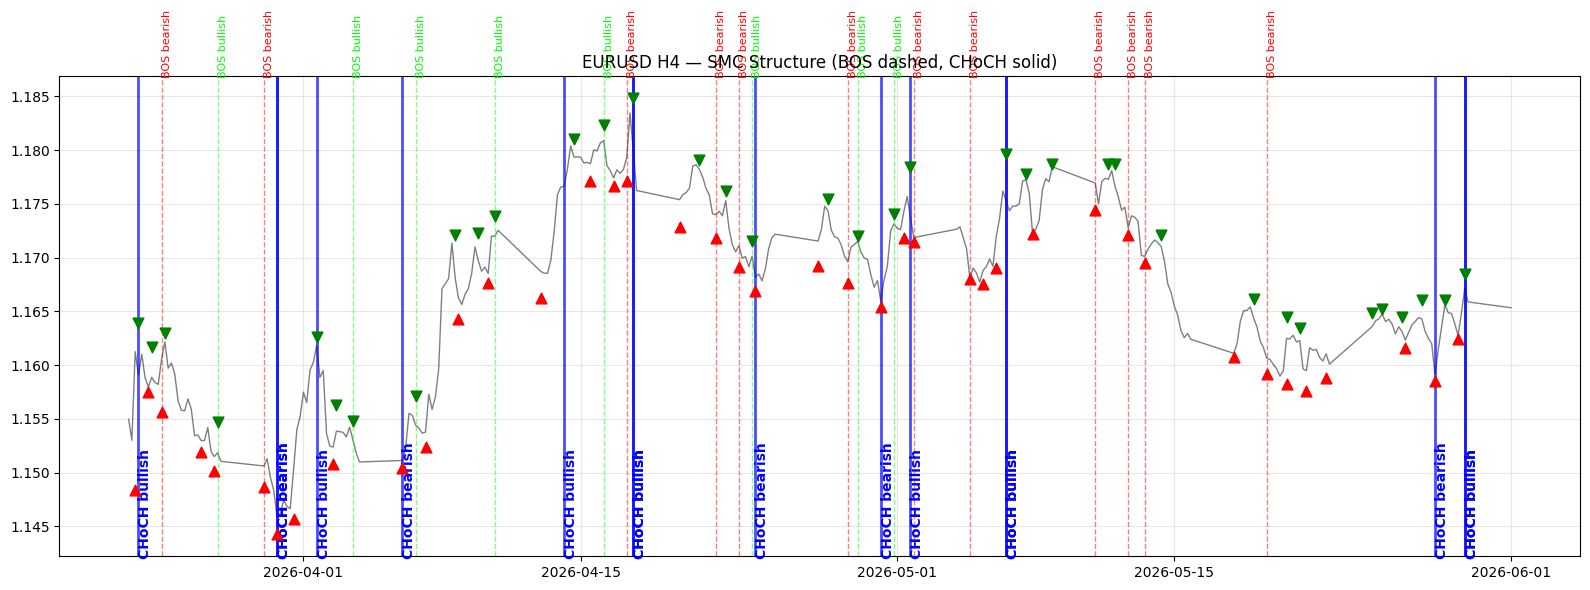

In [28]:
# Summary visualization
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index[-300:], df['close'].iloc[-300:], color='black', linewidth=1, alpha=0.5)

recent = swings[swings['index'] >= df.index[-300]]
for _, s in recent.iterrows():
    color = 'green' if s['type'] == 'swing_high' else 'red'
    marker = 'v' if s['type'] == 'swing_high' else '^'
    ax.scatter(s['index'], s['price'], color=color, marker=marker, s=60, zorder=5)

if len(bos) > 0:
    recent_bos = bos[bos['time'] >= df.index[-300]]
    for _, b in recent_bos.iterrows():
        color = 'lime' if b['direction'] == 'bullish' else 'red'
        ax.axvline(x=b['time'], color=color, linestyle='--', alpha=0.5, linewidth=1)
        ax.text(b['time'], ax.get_ylim()[1], f"BOS {b['direction']}",
                rotation=90, fontsize=8, color=color)

if len(choch) > 0:
    recent_choch = choch[choch['time'] >= df.index[-300]]
    for _, c in recent_choch.iterrows():
        ax.axvline(x=c['time'], color='blue', linestyle='-', alpha=0.7, linewidth=2)
        ax.text(c['time'], ax.get_ylim()[0], f"CHoCH {c['direction']}",
                rotation=90, fontsize=10, color='blue', fontweight='bold')

ax.set_title('EURUSD H4 — SMC Structure (BOS dashed, CHoCH solid)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()